## Introduction to Machine Learning

## Independent and Dependent Variable
- **Independent Variable**: A variable which value does not change by the effect of other variables and is used to manipulate the dependent variable. It often denoted as $X$.

- **Dependent Variable**: A variable whose value change when there is any manipulation in the values of independent variable. It is often denoted as $Y$

**Example**: Salary depends on years of experience

- **Salary**: Dependent Variable
- **Year of experience**: Independent Variable

## What is Linear Regression?
A statistical method that allows us to summarize and study relationships between two continuous (quantitative) variables.
- One variable, denoted $x$, is regarded as the **predictor**, **explanatory**, or **independent variable**.
- The other variable, $y$ denoted , is regarded as the **response**, **outcome**, or **dependent variable**.

In short, algorithms that learn how output($y$) depends on input($x$)
$$y = f(x)$$
The simplest form of $f$;
$y = mx + c$

## Simple Linear Regression Equation
The simplest form of a simple linear regression equation with one dependent and one independent variable is represented by:
$$y = mx +c$$

Where,
- $y$ = dependent variable
- $x$ = independent variable
- $m$ = slope of the line
- $c$ = coefficient of the line

$$ m = \frac{y_2 - y_1}{x_2 - x_1}$$

### Calculating slope(m) of the line

$$
m = r \frac{S_y}{S_x}
$$

Where,
- m = slope of the line
- r = pearson's r correlation
- $S_y$ = standard deviation of y
- $S_x$ = standard deviation of the x

Calculating y-intercept coefficient(c) of the line
$$
c = \overline y - m \overline x
$$

Where,
- c = intercept(c) or coefficient of the line
- m = slope of the line
- $\overline y$ mean of y
- $\overline x$ mean of x

## Multiple Linear Regression
$$
y = m_1x_1 + m_2x_2 + m_3x_3 + \cdots + m_nx_n + c
$$

- $x_1, x_2, x_3$ = independent/input variables
- $y$ = dependent/output variable
- $m_1, m_2, m_3$ = slopes
- $c$ = coefficient

In [ ]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# data
x_and_y = [(0, 1), (1, 3), (2, 2), (3, 5), (4, 7), (5, 8), (6, 8), (7, 9), (8, 10), (9,12)]
x_and_y

[(0, 1),
 (1, 3),
 (2, 2),
 (3, 5),
 (4, 7),
 (5, 8),
 (6, 8),
 (7, 9),
 (8, 10),
 (9, 12)]

In [ ]:
data = pd.DataFrame(x_and_y, columns=['x', 'y_true'])
data

,x,y_true
0,0,1
1,1,3
2,2,2
3,3,5
4,4,7
5,5,8
6,6,8
7,7,9
8,8,10
9,9,12


### Calculating Slope(m) of the Line
$$
m = r \frac{S_y}{S_x}
$$

Where,
- m = slope of the line
- r = pearson's r correlation
- $S_y$ = standard deviation of y
- $S_x$ = standard deviation of the x

In [ ]:
# calculate pearson's r correlation
data['x'].corr(data['y_true'])

np.float64(0.9759805523748861)

In [ ]:
# calculate the standard deviation of `x`
data['x'].std()

3.0276503540974917

In [ ]:
# calculate the standard deviation of `y`
data['y_true'].std()

3.6285901761795403

In [ ]:
m = 0.97 * (3.6/3.02)
m

1.1562913907284769

### Calculating y-intercept coefficient(c) of the line
$$
c = \overline y - m \overline x
$$

Where,
- c = intercept(c) or coefficient of the line
- m = slope of the line
- $\overline y$ mean of y
- $\overline x$ mean of x

In [ ]:
# calculate the mean of `y`
data['y_true'].mean()

np.float64(6.5)

In [ ]:
# calculate the mean of `x`
data['x'].mean()

np.float64(4.5)

In [ ]:
c = 6.5 - m * 4.5
c

1.2966887417218542

In [ ]:
data

,x,y_true
0,0,1
1,1,3
2,2,2
3,3,5
4,4,7
5,5,8
6,6,8
7,7,9
8,8,10
9,9,12


In [ ]:
y_pred = m * 1 + c
y_pred

2.452980132450331

In [ ]:
data['y_pred'] = m * data['x'] + c
data

,x,y_true,y_pred
0,0,1,1.296689
1,1,3,2.452980
2,2,2,3.609272
3,3,5,4.765563
4,4,7,5.921854
5,5,8,7.078146
6,6,8,8.234437
7,7,9,9.390728
8,8,10,10.547020
9,9,12,11.703311


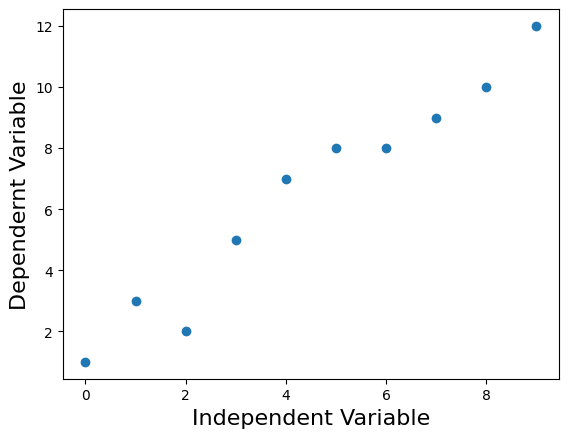

In [ ]:
plt.scatter(data['x'], data['y_true'])
plt.xlabel("Independent Variable", fontsize=16)
plt.ylabel("Dependernt Variable", fontsize=16)
plt.show()

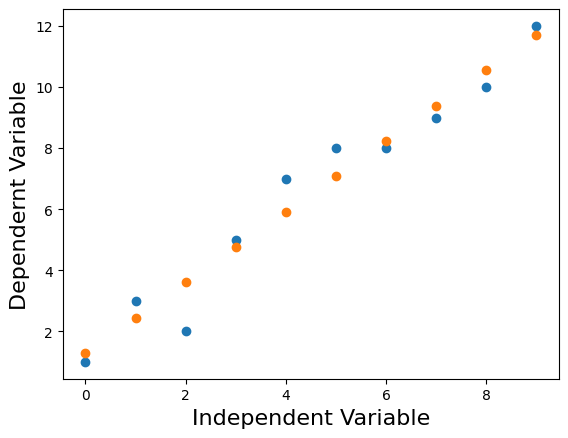

In [ ]:
# actual values
plt.scatter(data['x'], data['y_true'])

# predictions
plt.scatter(data['x'], data['y_pred'])

plt.xlabel("Independent Variable", fontsize=16)
plt.ylabel("Dependernt Variable", fontsize=16)
plt.show()

## Metrics for Evaluating Regression Model

In [ ]:
data

,x,y_true,y_pred
0,0,1,1.296689
1,1,3,2.452980
2,2,2,3.609272
3,3,5,4.765563
4,4,7,5.921854
5,5,8,7.078146
6,6,8,8.234437
7,7,9,9.390728
8,8,10,10.547020
9,9,12,11.703311


In [ ]:
# caculate errors
data['error'] = data['y_true'] - data['y_pred']
data

,x,y_true,y_pred,error
0,0,1,1.296689,-0.296689
1,1,3,2.452980,0.547020
2,2,2,3.609272,-1.609272
3,3,5,4.765563,0.234437
4,4,7,5.921854,1.078146
5,5,8,7.078146,0.921854
6,6,8,8.234437,-0.234437
7,7,9,9.390728,-0.390728
8,8,10,10.547020,-0.547020
9,9,12,11.703311,0.296689


### Absolute Error
---
$$\lvert y_t - y_p \rvert$$

Where,
- $y_t$ = true value of y
- $y_p$ = predicted value of y

In [ ]:
np.abs(data['error'])

,error
0,0.296689
1,0.547020
2,1.609272
3,0.234437
4,1.078146
5,0.921854
6,0.234437
7,0.390728
8,0.547020
9,0.296689


In [ ]:
data['abs_error'] = np.abs(data['error'])
data

,x,y_true,y_pred,error,abs_error
0,0,1,1.296689,-0.296689,0.296689
1,1,3,2.452980,0.547020,0.547020
2,2,2,3.609272,-1.609272,1.609272
3,3,5,4.765563,0.234437,0.234437
4,4,7,5.921854,1.078146,1.078146
5,5,8,7.078146,0.921854,0.921854
6,6,8,8.234437,-0.234437,0.234437
7,7,9,9.390728,-0.390728,0.390728
8,8,10,10.547020,-0.547020,0.547020
9,9,12,11.703311,0.296689,0.296689


### Mean Absolute Error(MAE)
---
- MAE represents the average absolute difference between the observed and predicted values.
- **Smaller MAE values** indicate better model performance.
- It gives an equal weight to all errors and does not square them, which makes it more robust to outliers compared to MSE.


**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_t- {y}_p|$$

In [ ]:
np.abs(data['error']).mean()

np.float64(0.6156291390728477)

In [ ]:
# calculate MAE using scikit-learn
from sklearn import metrics
metrics.mean_absolute_error(data['y_true'], data['y_pred'])

0.6156291390728477

### Mean Squared Error
---
- MSE represents the average of the squared differences between the actual and predicted values.
- **Smaller MSE values** indicate better model performance.
- It penalizes larger errors more heavily due to squaring the residuals.
- **Higher sensitivity to outliers** because of the squaring.

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_t-{y}_p)^2$$

In [ ]:
data

,x,y_true,y_pred,error,abs_error
0,0,1,1.296689,-0.296689,0.296689
1,1,3,2.452980,0.547020,0.547020
2,2,2,3.609272,-1.609272,1.609272
3,3,5,4.765563,0.234437,0.234437
4,4,7,5.921854,1.078146,1.078146
5,5,8,7.078146,0.921854,0.921854
6,6,8,8.234437,-0.234437,0.234437
7,7,9,9.390728,-0.390728,0.390728
8,8,10,10.547020,-0.547020,0.547020
9,9,12,11.703311,0.296689,0.296689


In [ ]:
data['sqerror'] = data['error'] ** 2
data

,x,y_true,y_pred,error,abs_error,sqerror
0,0,1,1.296689,-0.296689,0.296689,0.088024
1,1,3,2.452980,0.547020,0.547020,0.299231
2,2,2,3.609272,-1.609272,1.609272,2.589755
3,3,5,4.765563,0.234437,0.234437,0.054961
4,4,7,5.921854,1.078146,1.078146,1.162398
5,5,8,7.078146,0.921854,0.921854,0.849815
6,6,8,8.234437,-0.234437,0.234437,0.054961
7,7,9,9.390728,-0.390728,0.390728,0.152669
8,8,10,10.547020,-0.547020,0.547020,0.299231
9,9,12,11.703311,0.296689,0.296689,0.088024


In [ ]:
data['sqerror'].mean()

np.float64(0.5639068461909564)

In [ ]:
from sklearn import metrics
metrics.mean_squared_error(data['y_true'], data['y_pred'])

0.5639068461909564

### Root Mean Squared Error
---
- RMSE is the square root of the MSE, providing error values in the same units as the original data.
- **Smaller RMSE values** indicate better model performance.
- It is more sensitive to large errors compared to MAE, making it useful when large errors are undesirable.

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_t-{y}_p)^2}$$

In [ ]:
np.sqrt(data['sqerror'].mean())

np.float64(0.7509373117584159)

In [ ]:
from sklearn import metrics
metrics.root_mean_squared_error(data['y_true'], data['y_pred'])

0.7509373117584159

### $R^2$ Score
---
In statistics, the coefficient of determination, denoted $R^2$ or $r^2$ and pronounced "R squared", is the proportion of the variation in the dependent variable that is predictable from the independent variable.
$$
R^2 = \frac{1 - SSR}{SST}
$$

Where,
- $R^2$ = coefficient of determination
- SSR = sum of square of residuals(errors)
- SST = total sum of squares

$$
SST = \frac{\overline y_t}{\sigma}
$$

- $y_t$ = actual value
- $\sigma$ = standard deviations

### Key Points
---
- The most common and popular metric for evaluating regression
- Between 0 and 100%
- Unfortunately, always increases by adding new x variables
- Can lead to overfitting
- Adjusted R2 preferred for evaluating multiple regression

### Adjusted-$R^2$
---
- Adjusted-$R^2$ = $R^2$ x (Penalty for adding irrelevant variables)
- Increases if irrelevant* variables are deleted
- (*irrelevant variables = any group whose F-ratio < 1)
- **Higher values** indicate a better fitting model, but adjusted R² can decrease if unnecessary predictors are added to the model.


### Interpretation
---
- $r^2$ > 0.9; Good model
- $r^2$ = 1.0; Perfect model, it means zero error(SSR = 0)
- $r^2$ > 0.5; Bad model; mean model(SSR = SST)
- $r^2$ < 0; SSR > SST  

In [ ]:
from sklearn import metrics
print(metrics.r2_score(data['y_true'], data['y_pred']))

0.9524129243720711


Comparing these metrics:

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

# ESOL: Estimating Aqueous Solubility Directly from Molecular Structure
>  Delaney, John S. (2004). ESOL: estimating aqueous solubility directly from molecular structure. Journal of chemical information and computer sciences.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read the data
data = pd.read_csv("https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv")

In [ ]:
data.head()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.5954,167.850,0.0,0.0,-2.18
1,2.3765,133.405,0.0,0.0,-2.00
2,2.5938,167.850,1.0,0.0,-1.74
3,2.0289,133.405,1.0,0.0,-1.48
4,2.9189,187.375,1.0,0.0,-3.04


## Exploring Data

In [ ]:
# shape of the data (rows x columns)
data.shape

(1144, 5)

In [ ]:
# check data types
data.dtypes

,0
MolLogP,float64
MolWt,float64
NumRotatableBonds,float64
AromaticProportion,float64
logS,float64


In [ ]:
# check data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MolLogP             1144 non-null   float64
 1   MolWt               1144 non-null   float64
 2   NumRotatableBonds   1144 non-null   float64
 3   AromaticProportion  1144 non-null   float64
 4   logS                1144 non-null   float64
dtypes: float64(5)
memory usage: 44.8 KB


In [ ]:
# check missing values
data.isnull().sum()

,0
MolLogP,0
MolWt,0
NumRotatableBonds,0
AromaticProportion,0
logS,0


In [ ]:
# summary statistics of numerical variables
data.describe()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
count,1144.000000,1144.000000,1144.000000,1144.000000,1144.000000
mean,2.449133,204.631675,2.173951,0.364932,-3.057997
std,1.866003,102.620500,2.627398,0.343305,2.096502
min,-7.571400,16.043000,0.000000,0.000000,-11.600000
25%,1.414900,122.126000,0.000000,0.000000,-4.332250
50%,2.340300,183.594500,1.000000,0.375000,-2.870500
75%,3.406475,270.715750,3.000000,0.666667,-1.600000
max,10.388600,780.949000,23.000000,1.000000,1.580000


In [ ]:
# Correlations between Variables
data.corr()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
MolLogP,1.000000,0.468097,0.205607,0.250977,-0.827959
MolWt,0.468097,1.000000,0.394219,0.098855,-0.637324
NumRotatableBonds,0.205607,0.394219,1.000000,-0.296737,-0.238508
AromaticProportion,0.250977,0.098855,-0.296737,1.000000,-0.268108
logS,-0.827959,-0.637324,-0.238508,-0.268108,1.000000


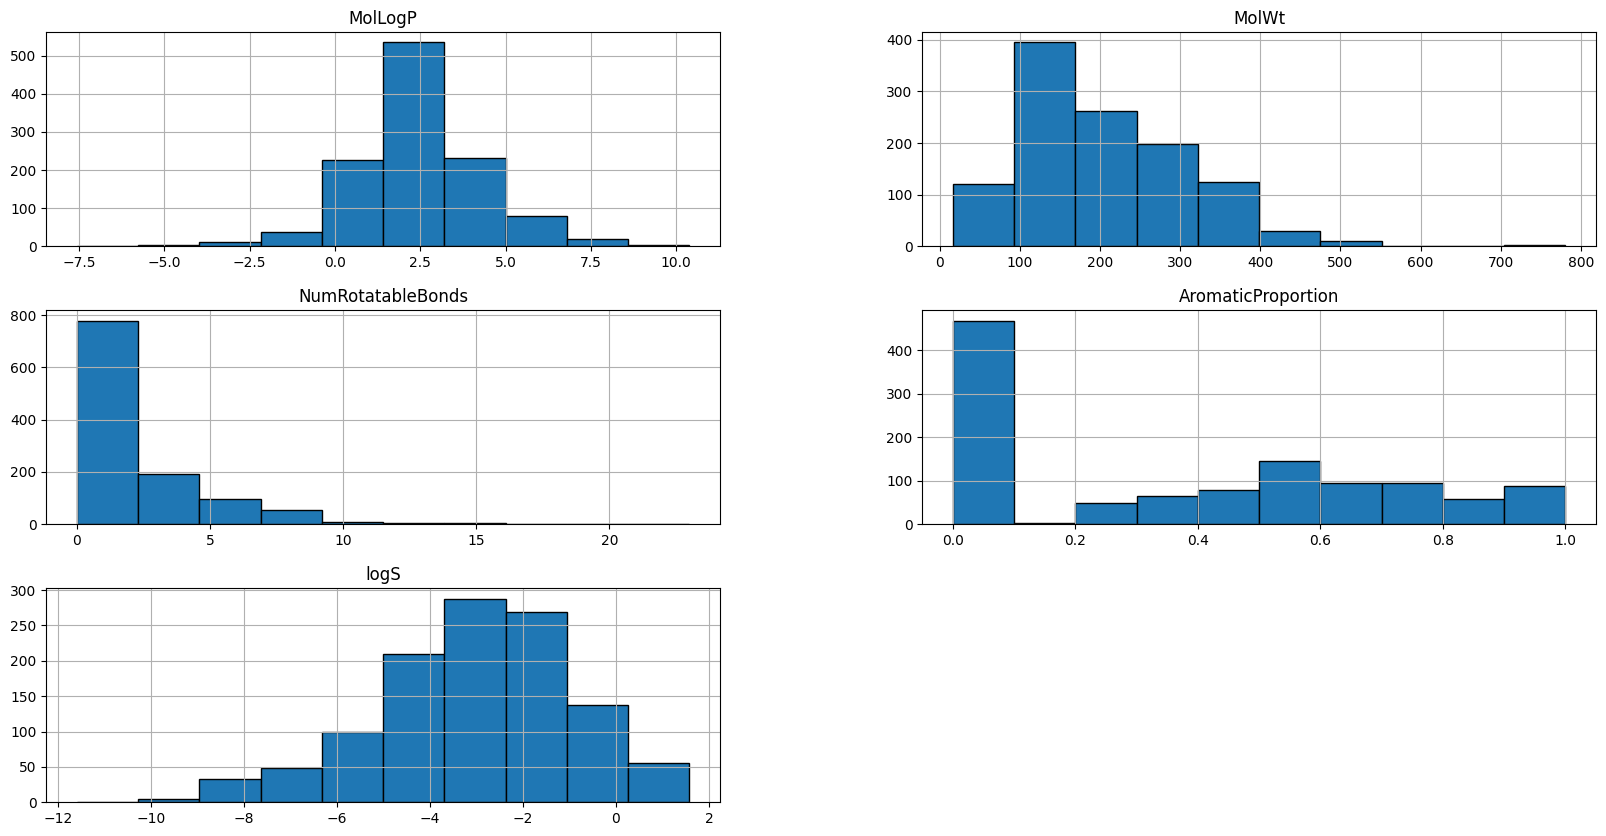

In [ ]:
# Univariate distributions with histogram
data.hist(figsize=(20,10), edgecolor="black")
plt.show()

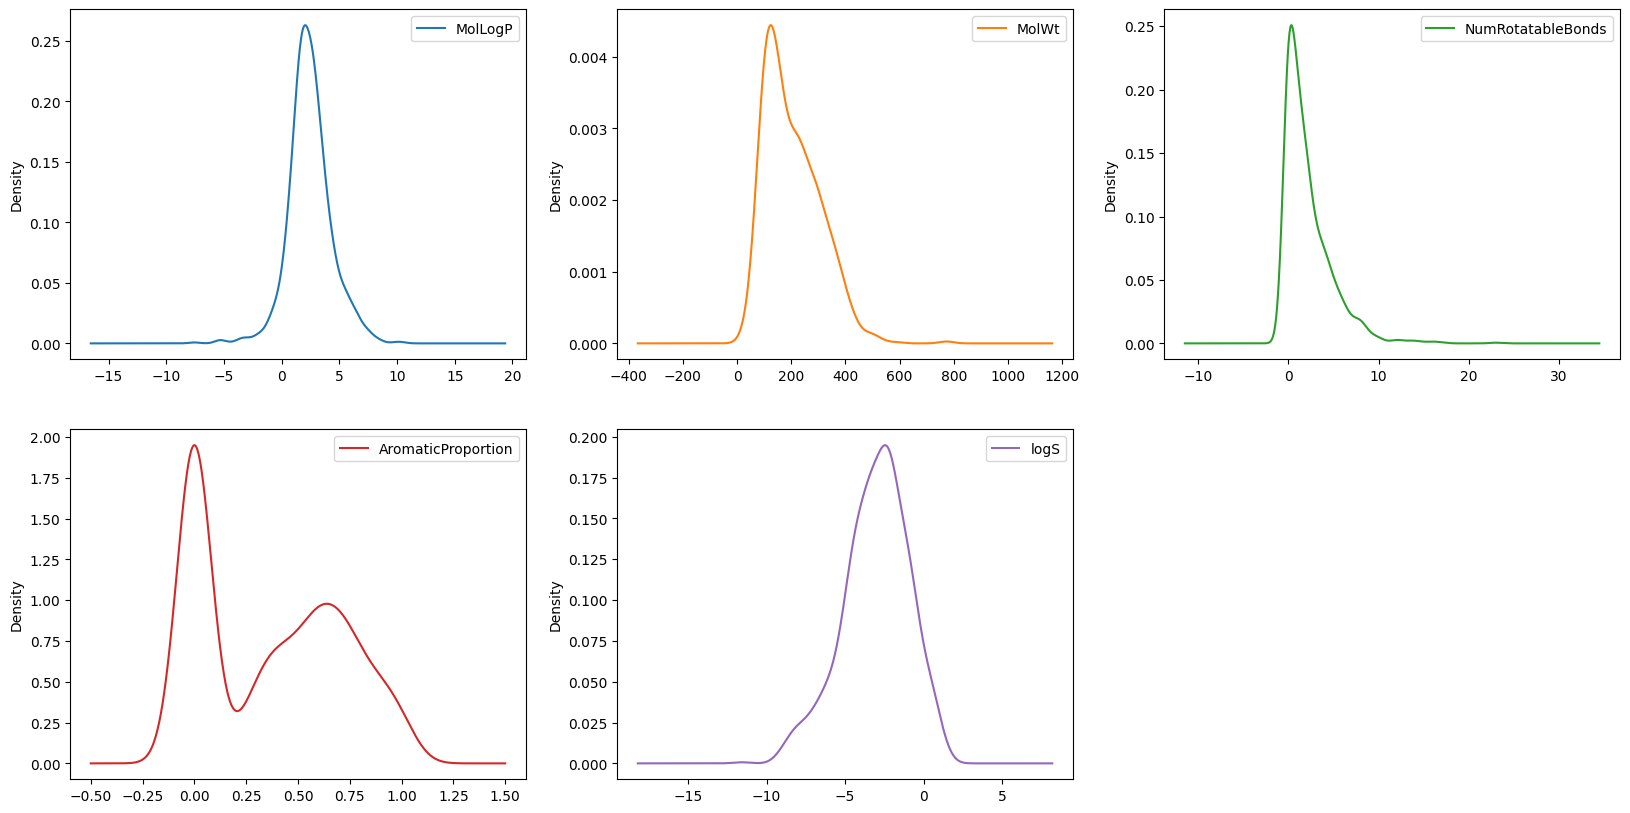

In [ ]:
# Univariate distributions with density plot
data.plot(kind="density", subplots=True, layout=(2,3), sharex=False, figsize=(20,10))
plt.show()

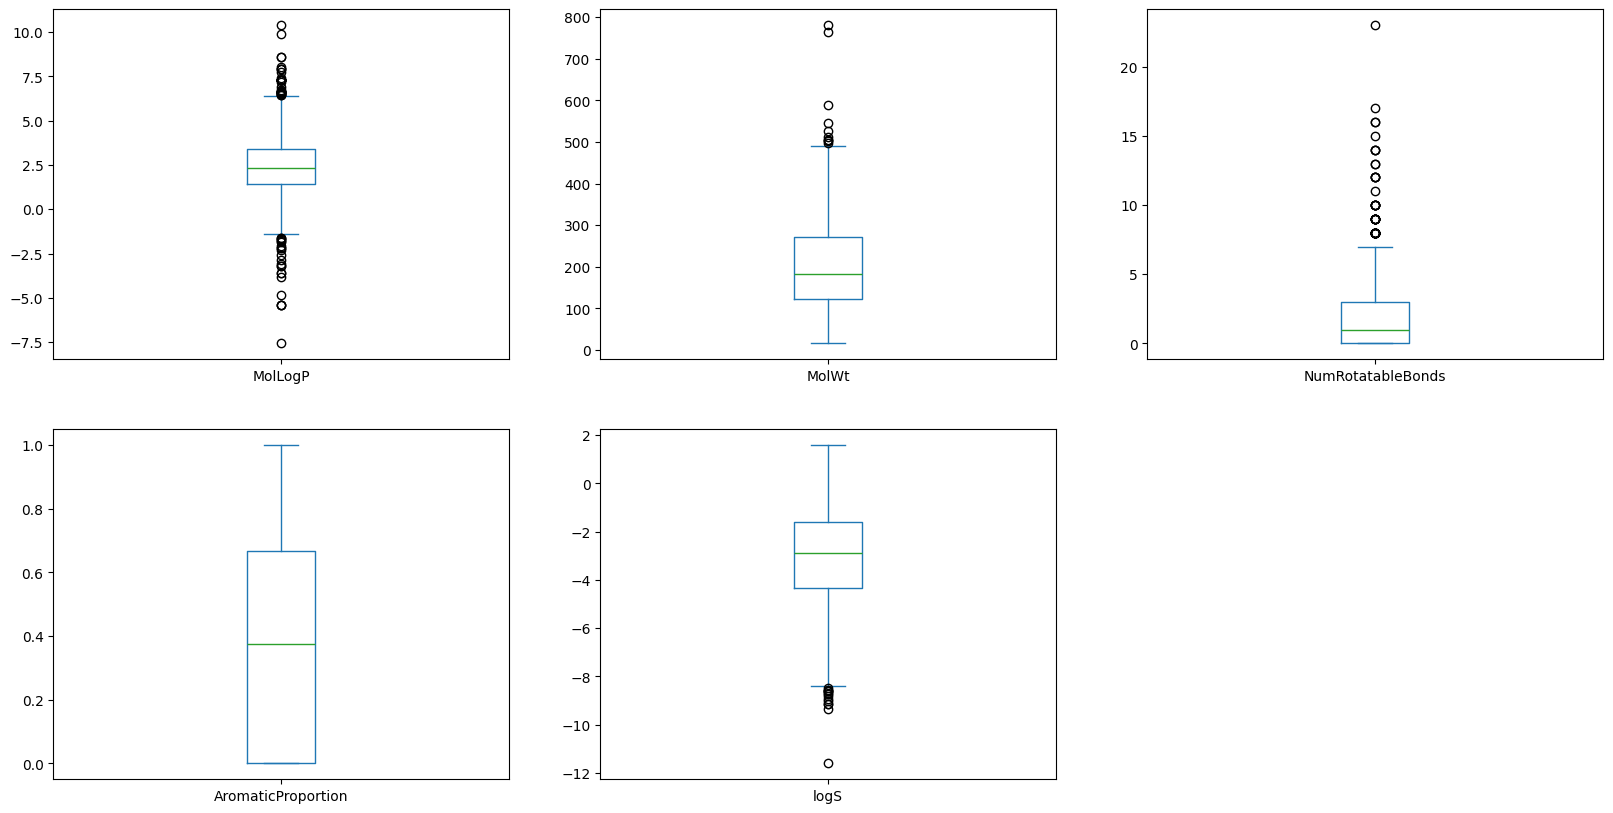

In [ ]:
# Univariate distributions with box plots
data.plot(kind='box', subplots=True, sharex=False, figsize=(20,10), layout=(2,3))
plt.show()

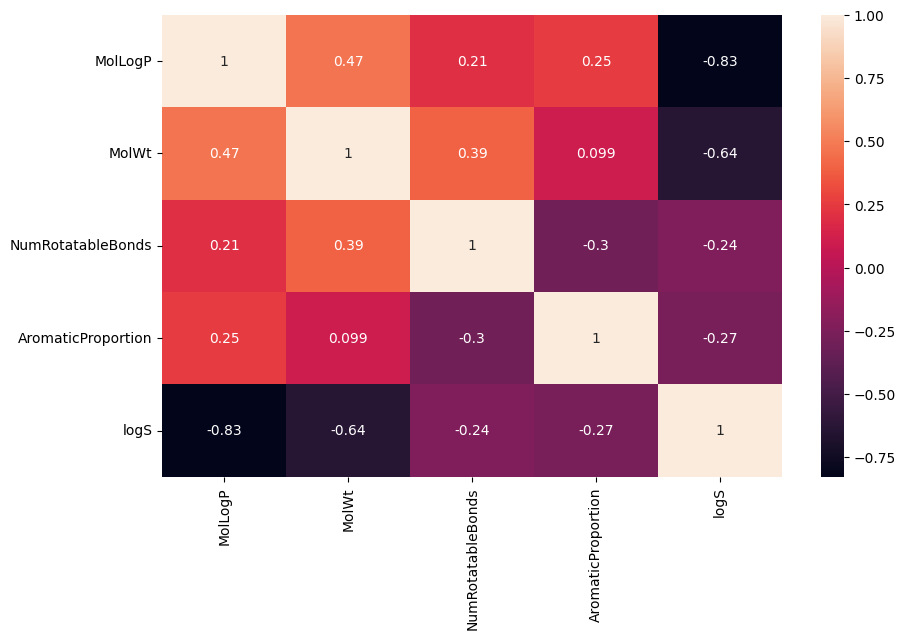

In [ ]:
# Multivariate plots with correlations
plt.figure(figsize=(10,6))
corr = data.corr()
sns.heatmap(corr, annot=True)
plt.show()

## Data Preparation: X and Y Data Matrices

In [ ]:
data.head()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.5954,167.850,0.0,0.0,-2.18
1,2.3765,133.405,0.0,0.0,-2.00
2,2.5938,167.850,1.0,0.0,-1.74
3,2.0289,133.405,1.0,0.0,-1.48
4,2.9189,187.375,1.0,0.0,-3.04


In [ ]:
y = data['logS']
y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


In [ ]:
X = data.drop('logS', axis=1)
X

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


## Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Display the shapes of the splits
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (915, 4)
X_test shape: (229, 4)
y_train shape: (915,)
y_test shape: (229,)


### Feature Engineering

The `MolLogP` feature, after the head of data was displayed, was observed to have a long tail to the left and is not normally distributed. We will apply a `log` transformation to this feature.

In [ ]:
from sklearn.preprocessing import RobustScaler

# Some values in MolLogP may be negative; let's apply a shift or power transform or simply scale using RobustScaler.
# Since we have outliers and non-normal distributions across features, we'll apply RobustScaler
# which uses statistics robust to outliers (median and IQR).

scaler = RobustScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Original features summary (train):")
display(X_train.describe())

print("\nScaled features summary (train) to mitigate outliers:")
display(X_train_scaled.describe())

Original features summary (train):


,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
count,915.000000,915.000000,915.000000,915.000000
mean,2.454049,203.598248,2.213115,0.358611
std,1.837974,101.845233,2.701293,0.343223
min,-7.571400,26.038000,0.000000,0.000000
25%,1.425730,121.655000,0.000000,0.000000
50%,2.337600,182.172000,1.000000,0.375000
75%,3.389900,270.372000,3.000000,0.666667
max,10.388600,780.949000,23.000000,1.000000



Scaled features summary (train) to mitigate outliers:


,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
count,915.000000,915.000000,915.000000,915.000000
mean,0.059287,0.144074,0.404372,-0.024584
std,0.935751,0.684826,0.900431,0.514834
min,-5.044879,-1.049873,-0.333333,-0.562500
25%,-0.464252,-0.406927,-0.333333,-0.562500
50%,0.000000,0.000000,0.000000,0.000000
75%,0.535748,0.593073,0.666667,0.437500
max,4.098932,4.026285,7.333333,0.937500


## Model Building and Evaluation

We will build and compare three distinct regression algorithms:
1. **Linear Regression**
2. **Random Forest Regressor**
3. **Gradient Boosting Regressor**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=100)
}

# Dictionary to store performance
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Fit
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Evaluate
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    results[name] = {
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train R2": train_r2,
        "Test R2": test_r2
    }

# Format results into a DataFrame
results_df = pd.DataFrame(results).T
results_df

,Train MSE,Test MSE,Train R2,Test R2
Linear Regression,1.007536,1.020695,0.764505,0.789162
Random Forest,0.086510,0.655515,0.979780,0.864594
Gradient Boosting,0.337380,0.671455,0.921143,0.861302


## Visualize Model Performance

Let's plot actual vs. predicted values for our best-performing model to understand its accuracy visually.

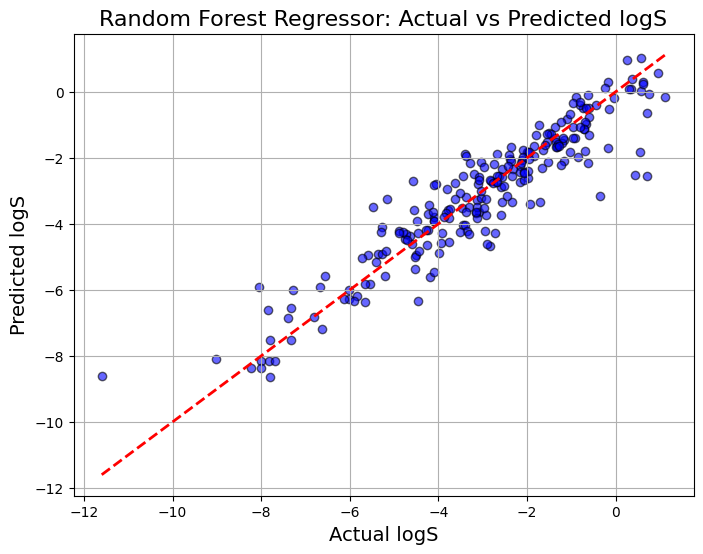

In [ ]:
# We will use the Random Forest model for visualization since tree-based ensembles usually perform very well on this dataset.
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual logS', fontsize=14)
plt.ylabel('Predicted logS', fontsize=14)
plt.title('Random Forest Regressor: Actual vs Predicted logS', fontsize=16)
plt.grid(True)
plt.show()